# Visium Breast Cancer

Data from multiple slides tutorial from SpottedPy:
https://github.com/secrierlab/SpottedPy/blob/main/spottedPy/tutorials/spottedPy_multiple_slides.ipynb

In [2]:
import scanpy as sc
import numpy as np
import squidpy as sq
import matplotlib.pyplot as plt

from graph_transformer_long_range_niches.pp import sliding_window

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [3]:
VISIUM_BREAST = '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/visium_breast_cancer.h5ad'  

In [4]:
adata_breast = sc.read_h5ad(VISIUM_BREAST)
adata_breast

AnnData object with n_obs × n_vars = 30562 × 14664
    obs: 'array_row', 'array_col', 'batch', 'angio_hallmarks', 'cell_prolif', 'tumour_cells', 'nk_cells', 'macro_siglec', 'EPI', 'EMT', 'hypoxia_hallmarks_hot', 'hypoxia_hallmarks_cold', 'angio_hallmarks_hot', 'angio_hallmarks_cold', 'macro_siglec_hot', 'macro_siglec_cold', 'nk_cells_hot', 'nk_cells_cold', 'EPI_hot', 'EPI_cold', 'EPI_hot_number', 'EPI_cold_number', 'EMT_hot', 'EMT_cold', 'EMT_hot_number', 'EMT_cold_number', 'angio_hallmarks_hot_number', 'angio_hallmarks_cold_number', 'macro_siglec_hot_number', 'macro_siglec_cold_number', 'nk_cells_hot_number', 'nk_cells_cold_number', 'response_to_check_point_score', 'globalX', 'globalY', 'sliding_window'
    uns: 'sliding_window_colors', 'spatial'
    obsm: 'MT', 'spatial'

## Normalization

In [7]:
scales_counts = sc.pp.normalize_total(adata_breast, target_sum=None, inplace=False)
# log1p transform
adata_breast.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [12]:
print(adata_breast.layers["log1p_norm"][:10, :10])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 19 stored elements and shape (10, 10)>
  Coords	Values
  (0, 6)	2.577779769897461
  (1, 7)	2.029308557510376
  (1, 6)	2.3899762630462646
  (2, 6)	2.8140151500701904
  (3, 6)	2.0699591636657715
  (4, 9)	1.5885272026062012
  (4, 7)	1.5885272026062012
  (4, 6)	3.866154670715332
  (5, 7)	0.6193034648895264
  (5, 6)	1.7434415817260742
  (6, 6)	1.5036736726760864
  (7, 7)	0.9639344215393066
  (7, 6)	1.7691690921783447
  (7, 1)	0.9639344215393066
  (8, 6)	3.437006950378418
  (9, 9)	0.26957258582115173
  (9, 7)	0.4816909432411194
  (9, 6)	1.3309513330459595
  (9, 1)	0.9349254369735718


In [14]:
adata_breast.X = adata_breast.layers["log1p_norm"]

## Sliding window

In [34]:
# Extract batch information from adata.obs
batches = adata_breast.obs['batch'].tolist()

# Create new obs_names using the batch information
new_obs_names = [
    f"{batch}_{i}"
    for batch, i in enumerate(batches)
]

# Assign the new obs_names to the adata object
adata_breast.obs_names = new_obs_names

adata_breast.obs_names = adata_breast.obs_names.str.replace('-', '', regex=False)

print(adata_breast.obs_names)
adata_breast.obs_names.astype(np.float64)

Index(['0_['0']', '0_['0']', '0_['0']', '0_['0']', '0_['0']', '0_['0']',
       '0_['0']', '0_['0']', '0_['0']', '0_['0']',
       ...
       '11_['11']', '11_['11']', '11_['11']', '11_['11']', '11_['11']',
       '11_['11']', '11_['11']', '11_['11']', '11_['11']', '11_['11']'],
      dtype='object', length=30562)


ValueError: could not convert string to float: "0_['0']"

: 

In [4]:
# counts data
adata_breast.X.data

array([1., 1., 2., ..., 1., 1., 2.], dtype=float32)

## Preprocessing

Transcriptome wide data! TODO: Do we need to filter out the cells?

In [5]:
TME_labels=['angio_hallmarks', 'macro_lam2','nk_cells']
EMT_labels=['EPI','EMT']

### Sliding window

In [6]:
# average number of cells per batch
print(adata_breast.obs.groupby('batch').size())

KeyError: 'batch'

In [7]:
# exclude batches that have approximatly 1k cells
#batch_nr = ['0', '2', '3', '4', '5', '7', '8', '10']
batch_nr = ['1', '6', '9', '11']

In [53]:
sliding_window(adata_breast, library_key = 'batch', window_size=9000, overlap=0)

In [54]:
for sliding_window_id in adata_breast.obs.columns[adata_breast.obs.columns.str.contains("sliding_window")]:
    for batch in batch_nr:
        adata_breast.obs.loc[adata_breast.obs['batch'] == batch, sliding_window_id] = batch

In [55]:
del adata_breast.uns['sliding_window_colors']

In [61]:
window_size = adata_breast.obs.groupby('sliding_window').size()
print(f"Nr cells per sliding window: Min: {window_size.min()}, Max: {window_size.max()}, Avg: {window_size.mean()}")

Nr cells per sliding window: Min: 3, Max: 2418, Avg: 898.8823529411765


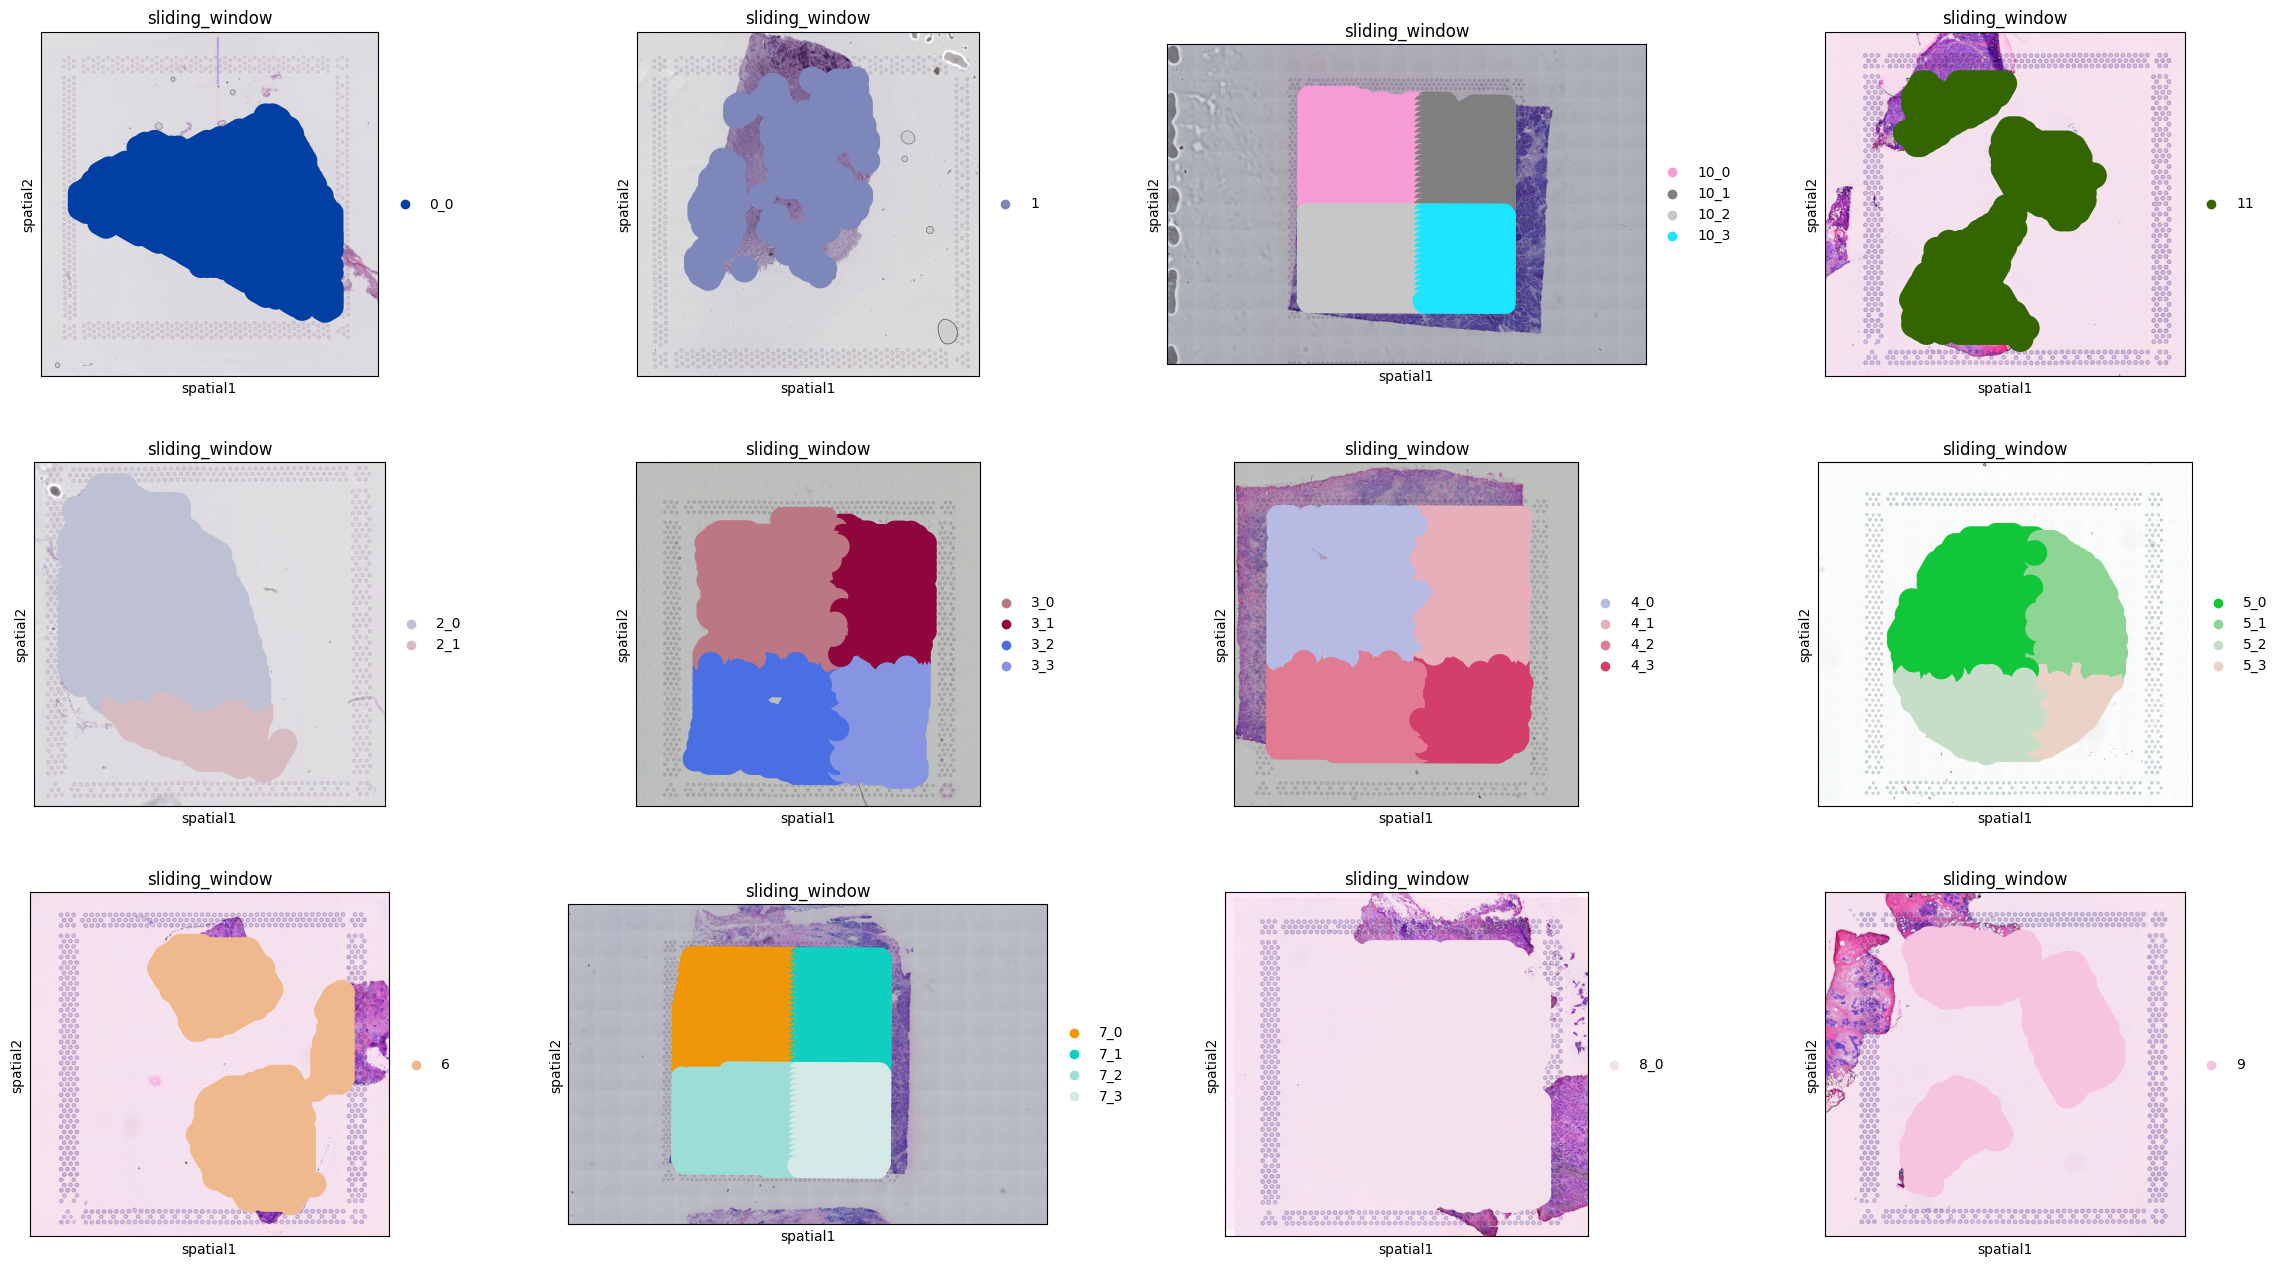

In [16]:
sq.pl.spatial_scatter(
    adata_breast,
    spatial_key = 'spatial',
    library_key='batch', 
    color="sliding_window", #cell_type_coarse",
    size = 10,
)

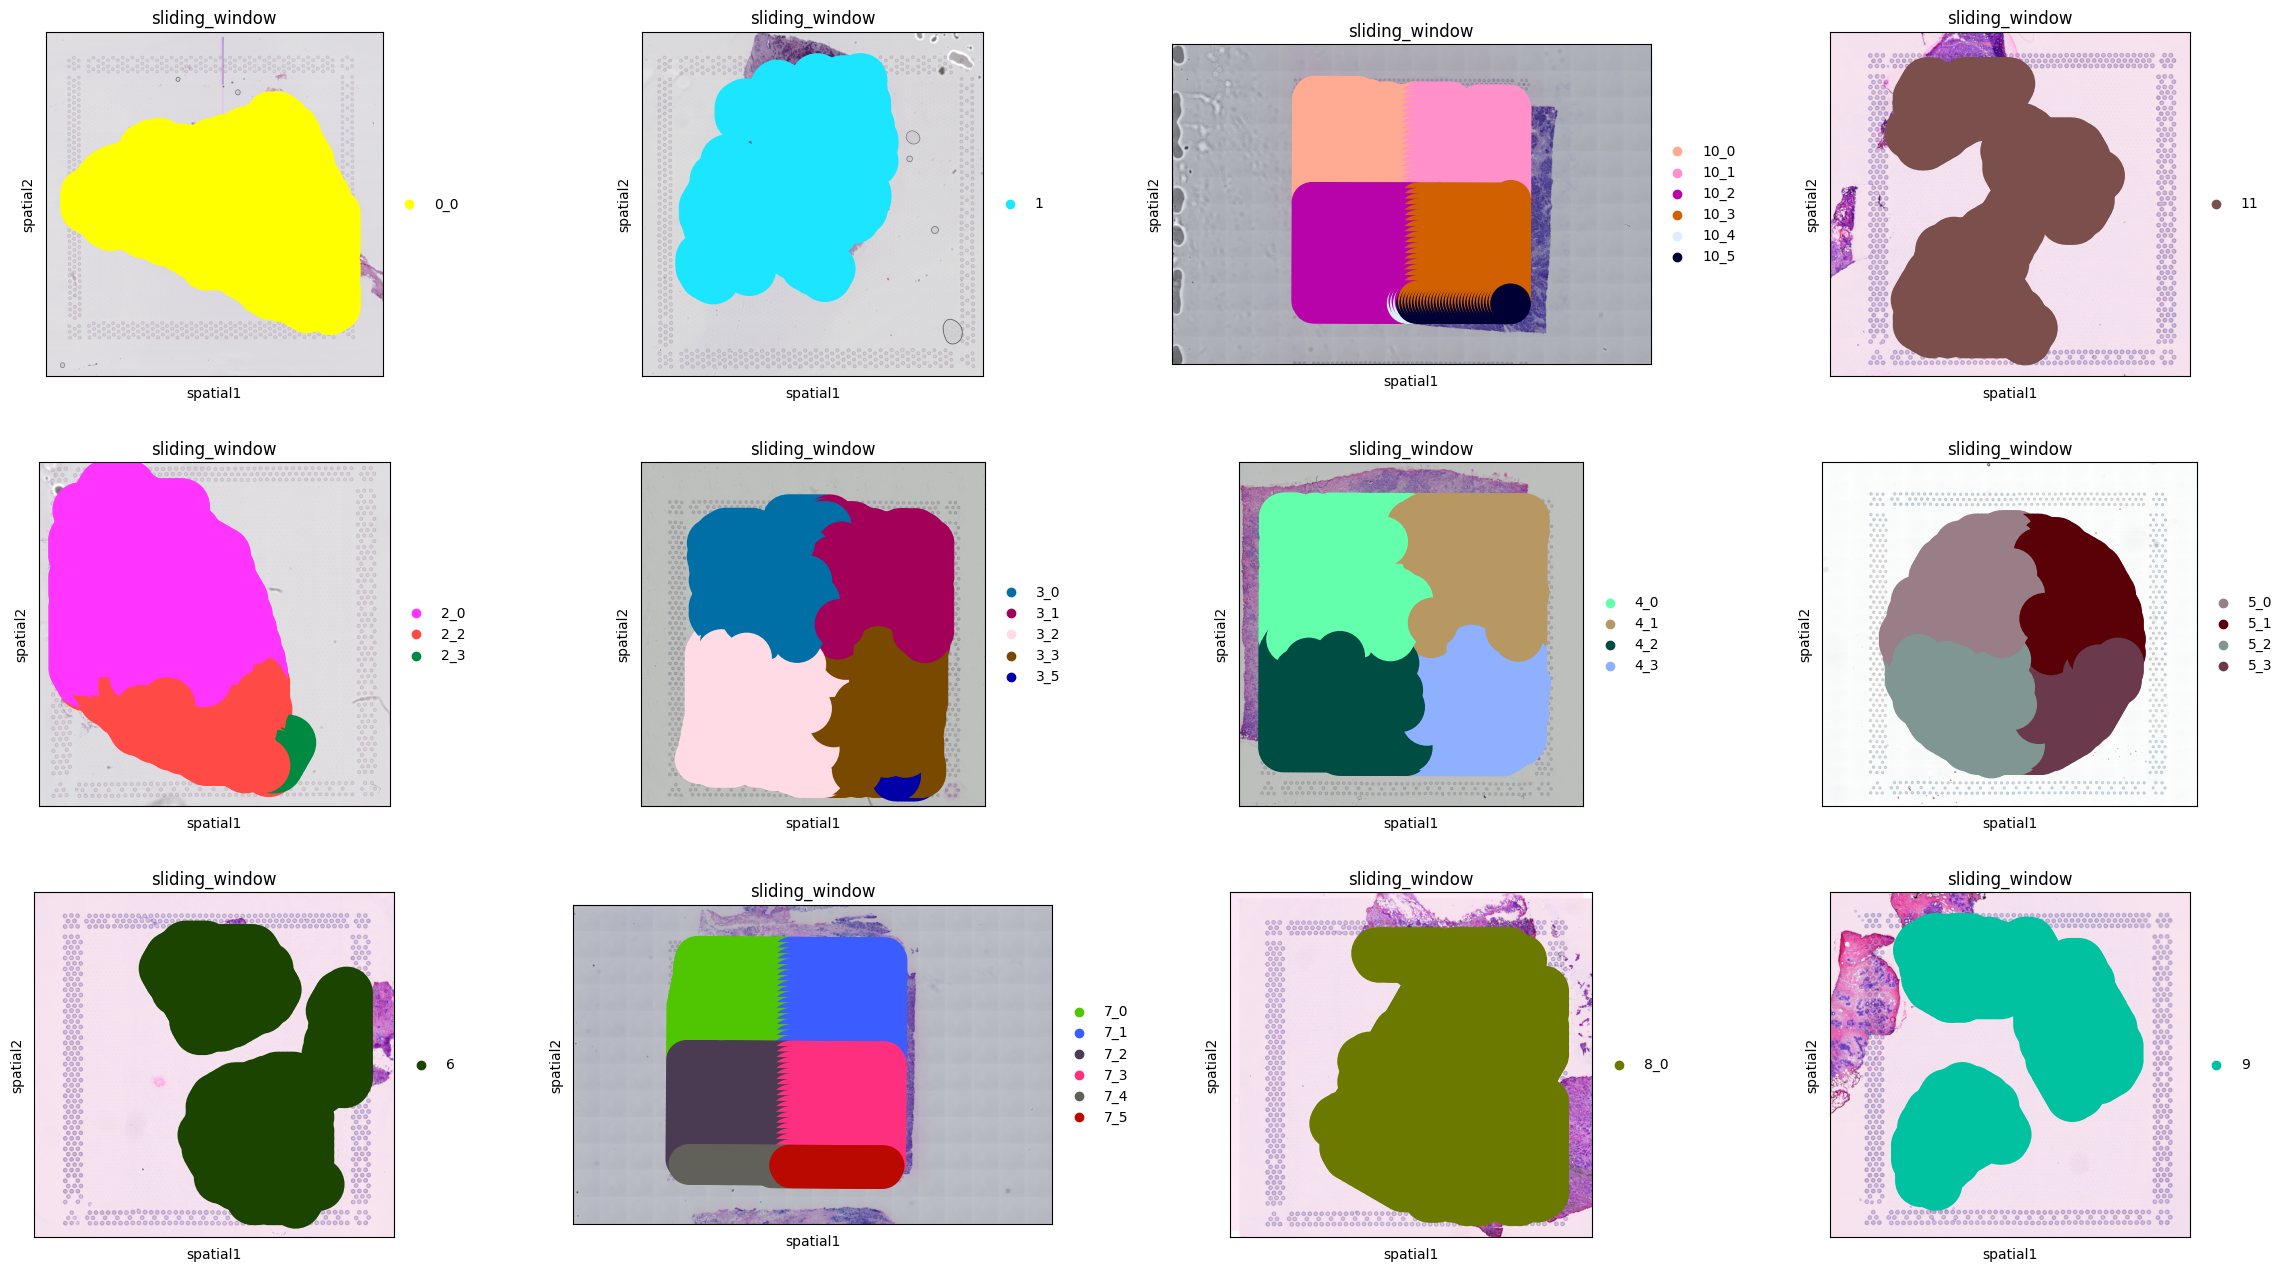

In [63]:
sq.pl.spatial_scatter(
    adata_breast,
    spatial_key = 'spatial',
    library_key='batch', 
    color="sliding_window", #cell_type_coarse",
    size = 10,
)

In [15]:
adata_breast.write(VISIUM_BREAST)